In [83]:
import pandas as pd
import numpy as np
import scanpy as sc
import squidpy as sq
import geopandas as gpd

In [84]:
# read h5 
spatial_data = sc.read_h5ad("/nfs/data3/mopitas/mapra/datasets/GSM6592049_M2/GSM6592049_M2.h5ad")

In [85]:
spatial_data.obs.to_dict(orient='index')

{'AAACAACGAATAGTTC-1': {'in_tissue': 0,
  'array_row': 0,
  'array_col': 16,
  'suspension_type': 'na',
  'assay_ontology_term_id': 'EFO:0022857',
  'Sample_ID': 'CL-like1',
  'organism_ontology_term_id': 'NCBITaxon:9606',
  'sex_ontology_term_id': 'PATO:0000383',
  'development_stage_ontology_term_id': 'HsapDv:0000258',
  'self_reported_ethnicity_ontology_term_id': 'unknown',
  'disease_ontology_term_id': 'MONDO:0005494',
  'tissue_type': 'tissue',
  'tissue_ontology_term_id': 'UBERON:0000310',
  'pathologist_annotation': nan,
  'B-cells': nan,
  'CAFs': nan,
  'Cancer Epithelial': nan,
  'Endothelial': nan,
  'Myeloid': nan,
  'Normal Epithelial': nan,
  'PVL': nan,
  'T-cells': nan,
  'stereoscope_annotation': nan,
  'cell_type_ontology_term_id': 'unknown',
  'is_primary_data': True,
  'treatment': 'untreated',
  'donor_id': 'CLB-37',
  'cell_type': 'unknown',
  'assay': 'Visium Spatial Gene Expression V1',
  'disease': 'triple-negative breast carcinoma',
  'organism': 'Homo sapiens

In [86]:
coords = pd.DataFrame(
    spatial_data.obsm["spatial"], 
    index=spatial_data.obs.index,      # barcodes
    columns=["x", "y"]
)

In [87]:
coords

,x,y
AAACAACGAATAGTTC-1,4686,1835
AAACAAGTATCTCCCA-1,18003,15195
AAACAATCTACTAGCA-1,8852,2623
AAACACCAATAACTGC-1,5215,17663
AAACAGAGCGACTCCT-1,16729,5541
...,...,...
TTGTTTCACATCCAGG-1,8760,17380
TTGTTTCATTAGTCTA-1,6912,17925
TTGTTTCCATACAACT-1,6432,13902
TTGTTTGTATTACACG-1,8623,21405


In [151]:
class Hexagons:
    def __init__(self, anndata, radius=5, scale=0.1):

        self.anndata = anndata
        self.radius = radius
        self.type = "FeatureCollection"
        self.geometry_type = "Polygon"
        self.scale = scale
        self.coordinates, self.centers = self.parse_coordinates()
        self.properties = self.parse_properties()
       
    
    def parse_properties(self):
        obs = self.anndata.obs
        properties = obs.copy()
        # Convert to dict with id as key and properties as values
        properties_dict = properties.to_dict(orient='index')
        return properties_dict
    
    def hexagon_points(self,x, y, radius):
        # Scale centers
        x = x * self.scale
        y = y * self.scale
        return [
            (x + radius * np.cos(np.pi / 3 * i), y + radius * np.sin(np.pi / 3 * i))
            for i in range(6)
        ] + [(x + radius * np.cos(0), y + radius * np.sin(0))]
        
    def parse_coordinates(self):
        anndata_spatial_coordinates = self.anndata.obsm["spatial"].copy()
        hex_coords = []
        coords = []
        for coord_tuple in anndata_spatial_coordinates:
            x, y = coord_tuple
            hexagon = self.hexagon_points(x=x, y=y, radius=self.radius)
            hex_coords.append(hexagon)
            coords.append([int(x) * self.scale, int(y) * self.scale])
        barcodes = self.anndata.obs.index
        # Convert to list of tuples (x, y)
        hex_coordinates_dict = [{barcode: hex_coord} for hex_coord, barcode in zip(hex_coords, barcodes)]
        coordinates_dict = {barcode: coord for barcode, coord in zip(barcodes, coords)}
        return hex_coordinates_dict, coordinates_dict


    
    def to_geojson(self):
        hexagons = {
                "type": "FeatureCollection",
                "features": []
            }
        for barcode, coords in zip(self.anndata.obs.index, self.coordinates):

            if self.properties[barcode]["in_tissue"] == False:
                continue

            hexagons["features"].append(
                {"type": "Feature",
                "geometry": {
                    "type": self.geometry_type,
                    "coordinates": [coords[barcode]]
                },
                "properties": {
                    "barcode": barcode,
                    "centroid": self.centers[barcode],
                    "cell_type": self.properties[barcode].get("cell_type", "unknown")
                    }
                }
            )
        
        return hexagons

        

In [152]:
hexagons = Hexagons(spatial_data, radius=50, scale=0.4)
geojson_data = hexagons.to_geojson()
geojson_data



{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'geometry': {'type': 'Polygon',
    'coordinates': [[(2136.0, 7065.200000000001),
      (2111.0, 7108.501270189223),
      (2061.0, 7108.501270189223),
      (2036.0, 7065.200000000001),
      (2061.0, 7021.898729810779),
      (2111.0, 7021.898729810779),
      (2136.0, 7065.200000000001)]]},
   'properties': {'barcode': 'AAACACCAATAACTGC-1',
    'centroid': [2086.0, 7065.200000000001],
    'cell_type': 'B cell'}},
  {'type': 'Feature',
   'geometry': {'type': 'Polygon',
    'coordinates': [[(1512.0, 5350.8),
      (1487.0, 5394.101270189222),
      (1437.0, 5394.101270189222),
      (1412.0, 5350.8),
      (1437.0, 5307.498729810778),
      (1487.0, 5307.498729810778),
      (1512.0, 5350.8)]]},
   'properties': {'barcode': 'AAACAGCTTTCAGAAG-1',
    'centroid': [1462.0, 5350.8],
    'cell_type': 'myeloid cell'}},
  {'type': 'Feature',
   'geometry': {'type': 'Polygon',
    'coordinates': [[(1760.4, 5779.200000000001),

In [153]:
# Save geojson data to a file
import json
with open("hexagons_GSM6592049_M2.geojson", "w") as f:
    json.dump(geojson_data, f, indent=4)

Text(0.5, 1.0, 'Hexagon for barcode: AAACACCAATAACTGC-1')

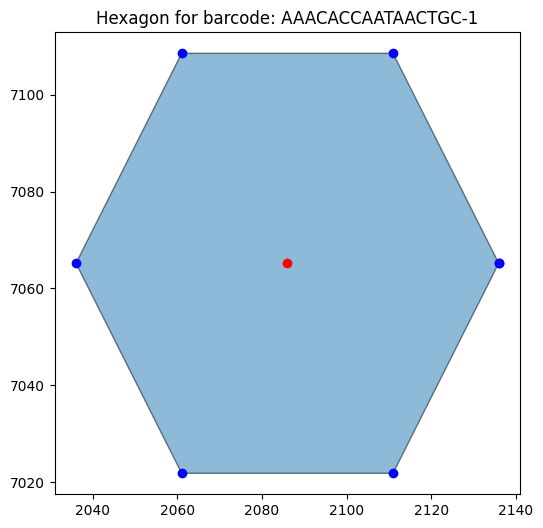

In [154]:
# plot one hexagon
import matplotlib.pyplot as plt
hexagon = geojson_data["features"][0]  # Get the first hexagon feature
plt.figure(figsize=(6, 6))
plt.fill(*zip(*hexagon["geometry"]["coordinates"][0]), alpha=0.5, edgecolor='black')
plt.scatter(*hexagon["properties"]["centroid"], color='red', label='Centroid')
plt.scatter(*zip(*hexagon["geometry"]["coordinates"][0]), color='blue', label='Hexagon Start')
plt.title(f"Hexagon for barcode: {hexagon['properties']['barcode']}")


In [155]:
import os
os.getcwd()

'/nfs/home/students/a.fomm/GitRepositories/mopitas-mapra/backend'

In [156]:
df_hexagons = gpd.read_file("hexagons_GSM6592049_M2.geojson")

Skipping field centroid: unsupported OGR type: 3


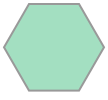

In [157]:
df_hexagons['geometry'][0]

In [158]:
# filepath: /nfs/home/students/a.fomm/GitRepositories/mopitas-mapra/backend/read_visium.ipynb
df_hexagons.is_valid[df_hexagons.is_valid == False]


Series([], dtype: bool)

In [159]:

df_hexagons.is_empty[df_hexagons.is_empty == True]

Series([], dtype: bool)

In [160]:
print(df_hexagons.total_bounds)

[ 857.2        1224.69872981 7316.8        8486.90127019]


<Axes: >

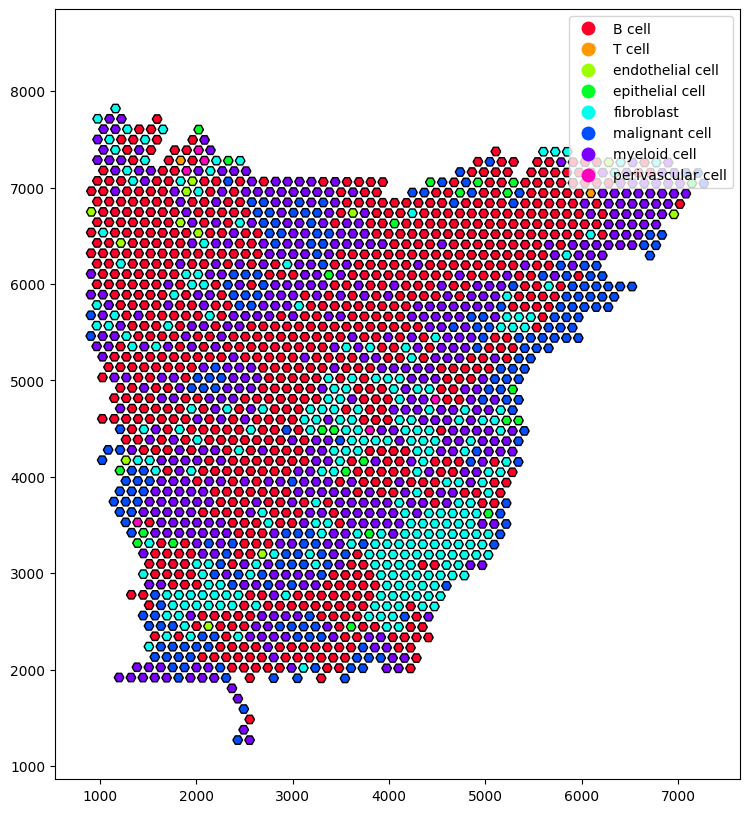

In [164]:
# or any projected CRS
df_hexagons.plot(figsize=(10, 10), edgecolor='black', aspect='equal',column="cell_type", legend=True, cmap="gist_rainbow", markersize=1)